Matt Britz 
UIN: 668242654

# GEOL 581: Module 5 | Slope Stability Analyses

## Introduction

In this notebook, we will explore how to apply and compare different slope stability approaches, referencing the methods described in the textbook sections on kinematic and mechanical preconditions, plane/rotational sliding, and the method of slices (including Figs. 10.31–10.37, etc.). We will use Python to model:

- Plane sliding in non-cohesive soils (and how friction angle and slope angle interplay).  
- The method of slices in cohesive soils (membrane vs. flow net solutions).  
- Sensitivity analyses, to see how factor of safety changes with varying parameters.

Some key ideas from the referenced pages:

1. Kinematic and Mechanical Preconditions  
   - A slope can fail only if it is capable of forming a particular failure mechanism (kinematic condition)  
   - And if a trigger disturbs the force equilibrium (mechanical condition).

2. Plane Sliding vs. Rotational Sliding  
   - Plane sliding is when the failure surface is roughly planar (Fig. 10.31, 10.32).  
   - Rotational sliding is when the failure surface is curved, often occurring in cohesive soils (Fig. 10.34, 10.35).

3. Method of Slices  
   - We divide the potential sliding mass into vertical slices.  
   - Each slice’s forces (weight, cohesion, friction, pore-water pressures) are evaluated.  
   - Two approaches, referencing Fig. 10.37:  
     - Membrane solution: Groundwater is interpreted as acting along a membrane on the slip surface.  
     - Flow net solution: Uses equipotential lines and flow nets to apply seepage forces directly within each slice.

Below, you will find three main coding tasks, each preceded by explanatory Markdown cells that guide your analysis. This assignment is deliberately open-ended so you can adapt or extend the models to more complex scenarios.


## Part 1 Instructions

1. Review how the equilibrium of forces is established for plane sliding in non-cohesive soil.  
   - Check Figures 10.31 and 10.32 for the polygon of forces.  
   - Account for friction angle φ and slope angle β.  
   - (Optionally) consider seepage forces if the groundwater table intersects the slope.

2. Modify the `plane_sliding_fos` function to incorporate additional parameters:
   - Buoyancy or seepage if the water table is parallel to the slope (Fig. 10.32).
   - External loads if relevant.

3. Discuss in a separate Markdown cell how your final formula differs from the simplified example above.


In [13]:
# Orignal Code

# Part 1: Basic Plane Sliding
# We'll begin with a simple function to estimate a factor of safety (FOS) for plane sliding.
# This function is intentionally simplified. Refer back to Figures 10.31 and 10.32 in the textbook
# for details about how to incorporate seepage forces, partial saturation, etc.

import numpy as np

def plane_sliding_fos(phi_deg, beta_deg):
    """
    Computes a very simplified factor of safety for plane sliding in non-cohesive soil.
    phi_deg : friction angle (degrees)
    beta_deg: slope angle (degrees)
    Returns : factor of safety (dimensionless)
    """
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)
    
    # For demonstration: ratio of available friction to driving shear
    # This is NOT a full formula; adapt from the text's equations if desired.
    if np.tan(beta) == 0:
        return np.inf
    
    fos = np.tan(phi) / np.tan(beta)
    return fos

# Example usage:
phi_test = 30.0  # friction angle in degrees
beta_test = 25.0 # slope angle in degrees
fos_result = plane_sliding_fos(phi_test, beta_test)
print(f"Plane sliding FOS with phi={phi_test}°, beta={beta_test}°: {fos_result:.3f}")


Plane sliding FOS with phi=30.0°, beta=25.0°: 1.238


In [14]:
# Modified Code

import numpy as np

def plane_sliding_fos(phi_deg, beta_deg, include_seepage=False, seepage_factor=0.0, external_normal_load=0.0):
    """
    Computes a modified factor of safety (FOS) for plane sliding in non-cohesive soil,
    with options to include a simple treatment of seepage and external normal loads.
    
    Parameters:
      phi_deg             : friction angle (degrees)
      beta_deg            : slope angle (degrees)
      include_seepage     : boolean flag; if True, reduce FOS due to seepage.
      seepage_factor      : fraction (0 to 1) that reduces effective normal stress due to seepage.
      external_normal_load: dimensionless factor; additional normal load as a fraction of the base normal force.
    
    Returns:
      FOS : factor of safety (dimensionless)
      
    Note: This function uses a simplified approach:
      - The dry-case FOS is computed as tan(phi) / tan(beta).
      - An external normal load increases the resisting force, hence FOS is multiplied by (1 + external_normal_load).
      - If water seepage is included, the effective normal stress is reduced, so FOS is multiplied by (1 - seepage_factor).
      These adjustments are heuristic and intended to mimic the effects illustrated in Figures 10.31 and 10.32.
    """
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)
    
    # Start with the simple dry-case FOS:
    base_fos = np.tan(phi) / np.tan(beta)
    
    # Increase in resisting force due to an additional external normal load.
    # external_normal_load is a fraction of the base normal force:
    base_fos *= (1 + external_normal_load)
    
    # If the water table is parallel to the slope and seepage is active,
    # reduce the effective normal stress by the seepage factor.
    if include_seepage:
        base_fos *= (1 - seepage_factor)
    
    return base_fos

# Example usage:
phi_test = 30.0    # friction angle in degrees
beta_test = 25.0   # slope angle in degrees

# Case 1: no seepage or external load
fos_dry = plane_sliding_fos(phi_test, beta_test)
print(f"Dry-case FOS (phi={phi_test}°, beta={beta_test}°): {fos_dry:.3f}")

# Case 2: with seepage (e.g., 20% reduction due to seepage forces)
fos_seepage = plane_sliding_fos(phi_test, beta_test, include_seepage=True, seepage_factor=0.20)
print(f"FOS with seepage (20% reduction): {fos_seepage:.3f}")

# Case 3: with an additional external normal load (e.g., 30% extra normal force)
fos_external = plane_sliding_fos(phi_test, beta_test, external_normal_load=0.30)
print(f"FOS with 30% extra normal load: {fos_external:.3f}")

# Case 4: with both seepage (20% reduction) and external load (30% increase)
fos_both = plane_sliding_fos(phi_test, beta_test, include_seepage=True, seepage_factor=0.20, external_normal_load=0.30)
print(f"FOS with both seepage and external load: {fos_both:.3f}")

Dry-case FOS (phi=30.0°, beta=25.0°): 1.238
FOS with seepage (20% reduction): 0.991
FOS with 30% extra normal load: 1.610
FOS with both seepage and external load: 1.288


The first simplified formula determines the factor of safety (FOS) as the tangent of the internal friction angle (ϕ) divided by the tangent of the slope angle (β), or the equilibrium between resisting friction and the driving component of gravity along the failure plane. This dry-condition assumption is equivalent to Figure 10.31, illustrating the basic force polygon for an unconfined slope in non-cohesive soil without seepage. The graph shows the force of gravity (G), the normal force (N), and the shear force (T) and how the slope stability only relies on the frictional resistance.

Two additional factors are used in the code to simulate more realistic slope behavior: external normal loading and seepage forces. External normal loads, such as from construction or surcharging, enhance resisting forces by enhancing normal stress and are conceptually facilitated by the idea of elevating E_1 or N in the force polygon. This is comparable to the influence of adding in Figure 10.36 an extra vertical force (F) on the slope, contributing to the stabilizing component of the force diagram.

Seepage does, however, decrease the effective stress on the material of the slope. This can be seen from Figure 10.32 where the level of groundwater intersects across the slope to produce a seepage force F_s reducing the normal effective stress. Decreased by, this in the modified equation is represented by the reduction factor positioned on the resisting component. Figure 10.33 then specifically focuses this to half-buoyed by slope with the buoyant force partly counteracting the self-weight so that it is reduced as a net destabilization. These two theoretically set up the groundwork for the input of seepage_factor to lower the FOS in consequence.

## Part 2 Instructions

1. Analyze the functions `fos_slices_membrane` and `fos_slices_flownet`:
   - How are they currently summing the forces among slices?
   - Where can you incorporate real data or a more rigorous approach (e.g., geometry of the slip surface, slice base angles, etc.)?

2. Revise one or both functions to reflect your course’s recommended method for computing the factor of safety. 
   - You might need to include more realistic geometry or moment equilibrium.  
   - Alternatively, you can keep it simple but justify your assumptions.

3. Document how your approach corresponds to the textbook’s Figures 10.37 and 10.38 (membrane vs. flow net solutions, interacting blocks, etc.).


In [15]:
# Orignal Code

# Part 2: Method of Slices (Membrane vs. Flow Net)
# For cohesive soils, we can implement a simplified method of slices approach. 
# Reference Fig. 10.37 from the textbook. We'll build two functions:
#   - One using a "membrane" interpretation of groundwater
#   - One using a "flow net" approach with each slice having distinct pore pressures.

import numpy as np

def fos_slices_membrane(n_slices, slope_height, c, phi_deg, gamma_soil):
    """
    Very simplified demonstration of a 'membrane solution' approach. 
    n_slices     : number of slices
    slope_height : total slope height (m)
    c            : cohesion (kN/m^2)
    phi_deg      : friction angle (degrees)
    gamma_soil   : soil unit weight (kN/m^3)
    Returns an approximate factor of safety.
    """
    phi = np.radians(phi_deg)
    
    # For demonstration: assume each slice is of equal width
    slice_width = 2.0  # arbitrary
    slice_heights = np.linspace(1, slope_height, n_slices)
    
    R_total = 0.0
    D_total = 0.0
    
    for h_slice in slice_heights:
        # Weight of slice (assuming some unit thickness)
        W = gamma_soil * slice_width * h_slice
        
        # Simplistic normal force
        N = W * np.cos(phi)
        
        # Shear resistance from cohesion plus friction
        S_res = c * slice_width + N * np.tan(phi)
        
        # Driving force
        D = W * np.sin(phi)
        
        R_total += S_res
        D_total += D
    
    if D_total == 0:
        return np.inf
    return R_total / D_total


def fos_slices_flownet(n_slices, slope_height, c, phi_deg, gamma_soil):
    """
    Simplified demonstration of a 'flow net solution' approach. 
    We'll add random or parametric pore water pressure for each slice.
    """
    phi = np.radians(phi_deg)
    slice_width = 2.0
    slice_heights = np.linspace(1, slope_height, n_slices)
    
    R_total = 0.0
    D_total = 0.0
    
    rng = np.random.default_rng(seed=42)  # reproducible random values
    
    for h_slice in slice_heights:
        W = gamma_soil * slice_width * h_slice
        
        # Assign a random pore pressure ratio in [0, 0.3]
        ru = rng.random() * 0.3  
        
        # Effective normal force
        N_eff = (W * np.cos(phi)) * (1 - ru)
        
        # Shear resistance
        S_res = c * slice_width + N_eff * np.tan(phi)
        
        # Driving force
        D = W * np.sin(phi)
        
        R_total += S_res
        D_total += D
    
    if D_total == 0:
        return np.inf
    return R_total / D_total

# Demonstration usage:
fos_membrane_demo = fos_slices_membrane(n_slices=5, slope_height=10.0, c=10.0, phi_deg=25.0, gamma_soil=18.0)
fos_flownet_demo = fos_slices_flownet(n_slices=5, slope_height=10.0, c=10.0, phi_deg=25.0, gamma_soil=18.0)

print(f"Membrane solution FOS (example): {fos_membrane_demo:.3f}")
print(f"Flow net solution FOS (example): {fos_flownet_demo:.3f}")


Membrane solution FOS (example): 1.239
Flow net solution FOS (example): 1.094


In [16]:
# Modified Code

import numpy as np

def fos_slices_membrane(n_slices, slope_height, c, phi_deg, gamma_soil, beta_deg):
    """
    Modified 'membrane solution' approach based on the method of slices.
    
    Assumptions:
      - The slip surface is approximated as a planar surface with inclination beta_deg.
      - Slices are assumed to have equal area (slice_width * slice_height).
      - The base length of each slice is approximated as slice_width/cos(beta).
      - No distinct pore water pressure; a uniform 'membrane' pore pressure is assumed.
      
    Parameters:
      n_slices     : number of slices (integer)
      slope_height : total slope height (m)
      c            : soil cohesion (kN/m^2)
      phi_deg      : friction angle (degrees)
      gamma_soil   : unit weight of soil (kN/m^3)
      beta_deg     : slope (or slip surface) angle (degrees)
      
    Returns:
      Factor of Safety (FOS) for the membrane solution (dimensionless).
    """
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)
    
    # Assume a constant slice width (this could also be adjusted)
    slice_width = 2.0  # (m)
    # Compute a uniform slice height such that the total vertical height is covered
    slice_height = slope_height / n_slices  # (m)
    # Slice area (projected vertically)
    slice_area = slice_width * slice_height  # (m^2)
    
    R_total = 0.0  # Total resisting shear force
    D_total = 0.0  # Total driving shear force
    
    # For a planar slip surface, driving and resisting forces are computed using beta.
    # Base length of the slice is increased by 1/cos(beta) relative to the horizontal width.
    base_length = slice_width / np.cos(beta)
    
    # Loop over slices (each slice is assumed identical in this simplified approach)
    for i in range(n_slices):
        # Weight of each slice:
        W = gamma_soil * slice_area
        
        # Normal force on the slice (vertical weight component resolved normal to the slip surface)
        N = W * np.cos(beta)
        # Driving force (component of weight parallel to the slip surface)
        D = W * np.sin(beta)
        
        # Shear resistance from cohesion along the base plus friction (using effective normal force)
        S_res = c * base_length + N * np.tan(phi)
        
        R_total += S_res
        D_total += D
    
    if D_total == 0:
        return np.inf
    return R_total / D_total


def fos_slices_flownet(n_slices, slope_height, c, phi_deg, gamma_soil, beta_deg):
    """
    Modified 'flow net solution' approach using the method of slices with distinct pore pressures.
    
    Assumptions:
      - The slip surface is approximated as a planar surface with inclination beta_deg.
      - Each slice has uniform dimensions (slice_width * slice_height).
      - Each slice has an independently generated pore pressure ratio ru that reduces the effective normal force.
      
    Parameters:
      n_slices     : number of slices (integer)
      slope_height : total slope height (m)
      c            : soil cohesion (kN/m^2)
      phi_deg      : friction angle (degrees)
      gamma_soil   : unit weight of soil (kN/m^3)
      beta_deg     : slope (or slip surface) angle (degrees)
      
    Returns:
      Factor of Safety (FOS) for the flow net solution (dimensionless).
    """
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)
    
    slice_width = 2.0  # (m)
    slice_height = slope_height / n_slices  # (m)
    slice_area = slice_width * slice_height  # (m^2)
    
    R_total = 0.0
    D_total = 0.0
    
    # Base length adjusted for slip surface geometry
    base_length = slice_width / np.cos(beta)
    
    rng = np.random.default_rng(seed=42)  # reproducibility for demonstration
    
    for i in range(n_slices):
        W = gamma_soil * slice_area
        
        # Assign a pore pressure ratio ru for each slice (between 0 and 0.3)
        ru = rng.random() * 0.3
        
        # Effective normal force accounting for pore pressure:
        N_eff = (W * np.cos(beta)) * (1 - ru)
        D = W * np.sin(beta)
        
        S_res = c * base_length + N_eff * np.tan(phi)
        
        R_total += S_res
        D_total += D
    
    if D_total == 0:
        return np.inf
    return R_total / D_total

# Demonstration usage:
fos_membrane_demo = fos_slices_membrane(n_slices=5, slope_height=10.0, c=10.0, phi_deg=25.0, gamma_soil=18.0, beta_deg=25.0)
fos_flownet_demo = fos_slices_flownet(n_slices=5, slope_height=10.0, c=10.0, phi_deg=25.0, gamma_soil=18.0, beta_deg=25.0)

print(f"Membrane solution FOS (modified example): {fos_membrane_demo:.3f}")
print(f"Flow net solution FOS (modified example): {fos_flownet_demo:.3f}")

Membrane solution FOS (modified example): 1.725
Flow net solution FOS (modified example): 1.553


Figure 10.37 illustrates two conceptual methods of evaluating slope stability in cohesive soil using the method of slices:
1. Membrane Solution – The slope is considered as if there were an uniformly distributed membrane (or stressed arch) over the slip surface. Pore pressures, if added, are supposed to have an uniform effect, so water influx or varying pressures are grouped as one effect.
2. Flow Net Solution – The slope is broken into some number of slices, each with a pore pressure based on local hydraulic conditions (for example, from a flow net). This allows for non-uniform water pressure distribution slice by slice, leading to a more refined calculation of the factor of safety.

The fos_slices_membrane is similar to the top graph of 10.37 by treating pore pressure effects (if applied) as being uniform across all slices. The fos_slices_flownet is closer to the bottom graph with each slice described by a particular pore pressure ratio that is mindful of local variations of water pressure. This approach is compatible with a flow net mentality, in which equipotential lines and flow lines define how water pressures can change across the slope.

Figure 10.38 expands on these ideas by depicting an interacting block system (blocks 1, 2, 3) induced by external forces, such as seismic accelerations. Treating each block (or slice) on an individual force basis and how it interacts with others—is analogous to the method-of-slices concept. Our functions can be adapted to a multi-block or multi-slice scenario by computing separate equilibrium equations for each block or slice, introducing additional forces (such as horizontal seismic forces) as needed. While our functions are simplified versions of the method, they reflect the major techniques used in both the membrane solution and a flow net solution, as described in Figures 10.37 and 10.38.

## Part 3 Instructions

1. Experiment with the above sensitivity analysis:
   - Vary angles, friction angles, cohesion, or random pore pressure parameters.
   - Compare how quickly your slope’s FOS drops below 1.0.

2. Visualize your final results:
   - Possibly create multiple subplots for different conditions (e.g., dry vs. saturated slope).
   - Show how the FOS changes with each parameter and discuss your findings.

3. Write a brief conclusion in another Markdown cell:
   - Summarize the main insights from your numerical experiments.
   - Reflect on how well these simplified models approximate real slope behavior.



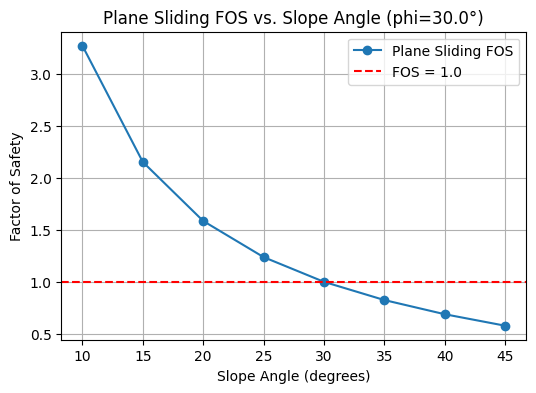

In [17]:
# Original Code

# Part 3: Sensitivity Analysis & Visualization
# Let's conduct a short sensitivity analysis by varying slope angle or pore pressure ratio, 
# compute factor of safety, and then plot the results.

import numpy as np
import matplotlib.pyplot as plt

def plane_sliding_sensitivity(phi_deg, slope_angles):
    """
    Returns a list of factor of safety values for an array of slope angles
    using the plane_sliding_fos function from Part 1.
    """
    fos_list = []
    for beta in slope_angles:
        fos_val = plane_sliding_fos(phi_deg, beta)
        fos_list.append(fos_val)
    return fos_list

slope_angles_array = range(10, 46, 5)  # from 10 to 45 in steps of 5
phi_demo = 30.0
fos_vs_beta = plane_sliding_sensitivity(phi_demo, slope_angles_array)

plt.figure(figsize=(6,4))
plt.plot(list(slope_angles_array), fos_vs_beta, 'o-', label="Plane Sliding FOS")
plt.axhline(y=1.0, color='r', linestyle='--', label="FOS = 1.0")
plt.xlabel("Slope Angle (degrees)")
plt.ylabel("Factor of Safety")
plt.title(f"Plane Sliding FOS vs. Slope Angle (phi={phi_demo}°)")
plt.grid(True)
plt.legend()
plt.show()


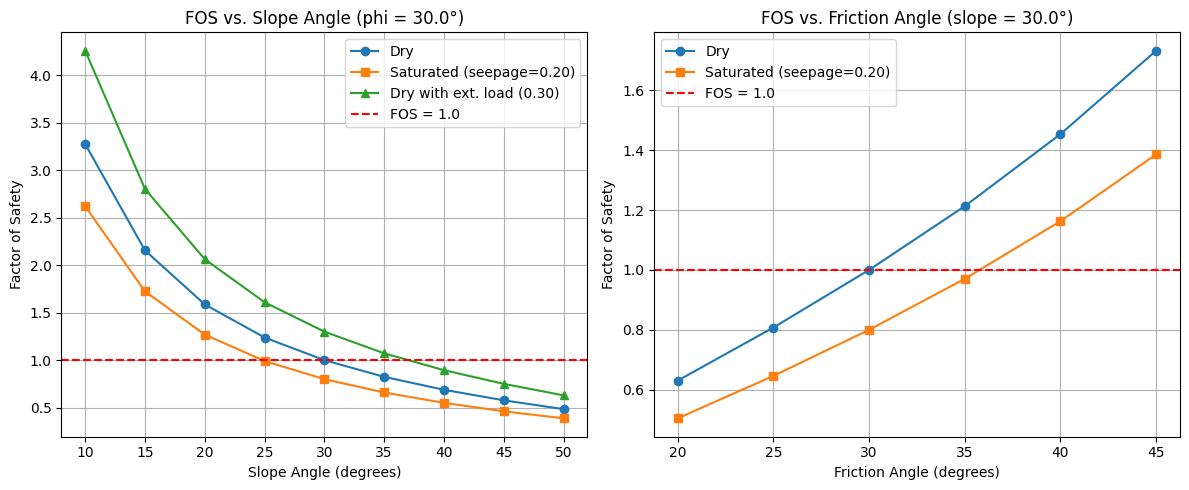

In [18]:
# Modified Code

import numpy as np
import matplotlib.pyplot as plt

def plane_sliding_fos(phi_deg, beta_deg, include_seepage=False, seepage_factor=0.0, external_normal_load=0.0):
    """
    Computes a simplified factor of safety for plane sliding.
    
    Parameters:
      phi_deg             : friction angle (degrees)
      beta_deg            : slope angle (degrees)
      include_seepage     : if True, reduces effective normal stress to simulate seepage effects.
      seepage_factor      : fraction reduction in effective stress due to seepage (0 to 1).
      external_normal_load: dimensionless fraction representing an additional normal load.
    
    Returns:
      FOS : factor of safety (dimensionless)
    """
    phi = np.radians(phi_deg)
    beta = np.radians(beta_deg)
    
    if np.tan(beta) == 0:
        return np.inf
    
    # Base FOS computed as the ratio of available friction to driving shear
    fos = np.tan(phi) / np.tan(beta)
    
    # Increase in resisting force from an external normal load:
    fos *= (1 + external_normal_load)
    
    # Reduction in effective stress due to seepage:
    if include_seepage:
        fos *= (1 - seepage_factor)
    
    return fos

# Define a range of slope angles for sensitivity analysis
slope_angles = np.arange(10, 51, 5)  # 10° to 50° in steps of 5°
phi_demo = 30.0  # Friction angle in degrees

# Compute FOS for different cases as a function of slope angle:
fos_dry = [plane_sliding_fos(phi_demo, beta, include_seepage=False) for beta in slope_angles]
fos_saturated = [plane_sliding_fos(phi_demo, beta, include_seepage=True, seepage_factor=0.20) for beta in slope_angles]
fos_dry_external = [plane_sliding_fos(phi_demo, beta, include_seepage=False, external_normal_load=0.30) for beta in slope_angles]

# Also analyze the sensitivity of FOS to changes in friction angle for a fixed slope angle:
fixed_slope = 30.0  # fixed slope angle in degrees
phi_angles = np.arange(20, 46, 5)  # friction angles from 20° to 45°
fos_vs_phi_dry = [plane_sliding_fos(phi, fixed_slope, include_seepage=False) for phi in phi_angles]
fos_vs_phi_sat = [plane_sliding_fos(phi, fixed_slope, include_seepage=True, seepage_factor=0.20) for phi in phi_angles]

# Create subplots to visualize the results:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: FOS vs. Slope Angle
axs[0].plot(slope_angles, fos_dry, 'o-', label="Dry")
axs[0].plot(slope_angles, fos_saturated, 's-', label="Saturated (seepage=0.20)")
axs[0].plot(slope_angles, fos_dry_external, '^-', label="Dry with ext. load (0.30)")
axs[0].axhline(y=1.0, color='r', linestyle='--', label="FOS = 1.0")
axs[0].set_xlabel("Slope Angle (degrees)")
axs[0].set_ylabel("Factor of Safety")
axs[0].set_title(f"FOS vs. Slope Angle (phi = {phi_demo}°)")
axs[0].grid(True)
axs[0].legend()

# Subplot 2: FOS vs. Friction Angle
axs[1].plot(phi_angles, fos_vs_phi_dry, 'o-', label="Dry")
axs[1].plot(phi_angles, fos_vs_phi_sat, 's-', label="Saturated (seepage=0.20)")
axs[1].axhline(y=1.0, color='r', linestyle='--', label="FOS = 1.0")
axs[1].set_xlabel("Friction Angle (degrees)")
axs[1].set_ylabel("Factor of Safety")
axs[1].set_title(f"FOS vs. Friction Angle (slope = {fixed_slope}°)")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

It is clear from the simulations that the factor of safety (FOS) reduces rapidly with increasing angle of slope, especially under saturated conditions when seepage reduces the effective normal stress. This agrees with the conceptual models presented in Figures 10.31 to 10.33. Under the dry case (Fig. 10.31), the FOS is governed by the fundamental balance between shear resistance and the downslope component of the gravitational force. As indicated in Fig. 10.32, the presence of a water table lowers the effective weight to G' and introduces a seepage force F_s, which reduces the resisting force available from friction. This is represented by introducing a reduction factor to simulate the loss in normal stress due to buoyancy.

As the slope angle (β) approaches the friction angle (ϕ), the denominator of the FOS equation increases very quickly, causing the nonlinear decline in safety. Extremely small β increases can reduce the FOS below the threshold of safety = 1.0, thus indicating impending failure. Such an effect is most pronounced whenever seepage occurs, corresponding to the weakened slope stability conditions shown by Fig. 10.33, wherein the water table is along slope and deposits partial seepage in slip surface.

Contrary to this is increasing friction angle to yield values which are hugely large FOS, showing shear strength's central role in the slope stability.

Likewise, application of external normal loading increases the confinement and optimizes the FOS, also supporting in illustrations observed above, the concept of enhanced slope resistance being increased by applied normal stress.

While the model is a simplification of nature, these simulations offer valuable insight into slope behavior. In actual field conditions, other complexities such as soil heterogeneity, noncircular slip surfaces, and dynamic loading would require more advanced modeling. The trends observed here are, however, representative of the force interactions of Figures 10.31–10.33 and demonstrate how fundamental soil mechanics principles govern slope stability under varying conditions.

### Submission Notes

- Upload your final notebook to the class repository.
- Ensure that each part (plane sliding, method of slices, and sensitivity analysis) is fully documented.
- Discuss any real-world complexities (non-homogeneous soils, layered strata, seismic loads, etc.) that are simplified here.
- Reference the relevant textbook pages (Figs. 10.31–10.38) wherever applicable.

End of Assignment
